In [145]:
import pandas as pd
import numpy as np
import pickle

In [146]:
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [147]:
df = pd.read_csv("D:/student_performance_predictor/dataset/cleaned_dataset.csv")

In [148]:
df["Study_Efficiency"] = (
    df["Hours_Studied"] /
    (df["Sleep_Hours"] + 1)
)

df["Academic_Consistency"] = (
    df["Attendance"] *
    df["Previous_Scores"]
)

df["Study_Commitment"] = (
    df["Hours_Studied"] *
    df["Attendance"]
)

In [149]:
X = df[
    [
        "Hours_Studied",
        "Attendance",
        "Previous_Scores",
        "Tutoring_Sessions",
        "Sleep_Hours",
        "Physical_Activity",

        "Study_Efficiency",
        "Academic_Consistency",
        "Study_Commitment",

        "Access_to_Resources",
        "Motivation_Level",
        "Teacher_Quality",
        "Parental_Involvement",

        "Internet_Access",
        "Family_Income",
        "School_Type",
        "Peer_Influence",
        "Parental_Education_Level",
        "Distance_from_Home",
        "Gender"
    ]
]

y = df["Exam_Score"]

In [150]:
X.isnull().sum()

Hours_Studied               0
Attendance                  0
Previous_Scores             0
Tutoring_Sessions           0
Sleep_Hours                 0
Physical_Activity           0
Study_Efficiency            0
Academic_Consistency        0
Study_Commitment            0
Access_to_Resources         0
Motivation_Level            0
Teacher_Quality             0
Parental_Involvement        0
Internet_Access             0
Family_Income               0
School_Type                 0
Peer_Influence              0
Parental_Education_Level    0
Distance_from_Home          0
Gender                      0
dtype: int64

In [151]:
X = pd.get_dummies(X, drop_first=True,dtype=int)

In [152]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [153]:
# model_1
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [154]:
# model_2
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [155]:
# model_3
xgb = XGBRegressor(
    n_estimators=700,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [156]:
models = {
    "Linear Regression": lr_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

for name, pred in models.items():

    r2 = r2_score(y_test, pred)

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, pred)
    )

    print("\n", name)

    print("R²  :", round(r2, 4))

    print("MAE :", round(mae, 4))

    print("RMSE:", round(rmse, 4))


 Linear Regression
R²  : 0.5765
MAE : 0.7919
RMSE: 2.8382

 Random Forest
R²  : 0.6967
MAE : 1.2358
RMSE: 2.4021

 XGBoost
R²  : 0.7669
MAE : 0.9107
RMSE: 2.1059


In [157]:
cv_scores = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("\nCross Validation R²")

print(cv_scores)

print("Mean CV R²:", cv_scores.mean())


Cross Validation R²
[0.77601838 0.81246328 0.78899014 0.82505172 0.70500368]
Mean CV R²: 0.7815054416656494


In [158]:
scores = {
    "Linear Regression":
        r2_score(y_test, lr_pred),

    "Random Forest":
        r2_score(y_test, rf_pred),

    "XGBoost":
        r2_score(y_test, xgb_pred)
}

best_model_name = max(
    scores,
    key=scores.get
)

print("\nBest Model:", best_model_name)


Best Model: XGBoost


In [159]:
if best_model_name == "Linear Regression":
    best_model = lr

elif best_model_name == "Random Forest":
    best_model = rf

else:
    best_model = xgb

pickle.dump(
    best_model,
    open("model.pkl", "wb")
)

pickle.dump(
    X.columns.tolist(),
    open("columns.pkl", "wb")
)

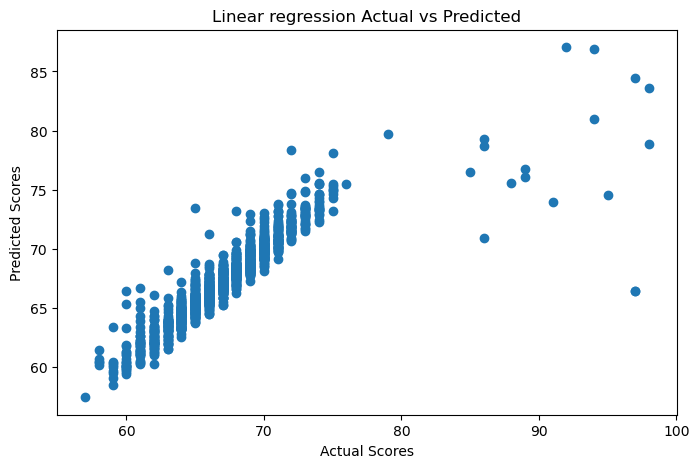

In [160]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    xgb_pred
)

plt.xlabel("Actual Scores")

plt.ylabel("Predicted Scores")

plt.title(
    "Linear regression Actual vs Predicted"
)

plt.show()

In [161]:
weak = pd.DataFrame({
    "Hours_Studied":[5],
    "Attendance":[65],
    "Previous_Scores":[55],
    "Tutoring_Sessions":[1],
    "Sleep_Hours":[6],
    "Physical_Activity":[2],

    "Access_to_Resources":["Low"],
    "Motivation_Level":["Low"],
    "Teacher_Quality":["Low"],
    "Parental_Involvement":["Low"],

    "Internet_Access":["No"],
    "Family_Income":["Low"],
    "School_Type":["Public"],
    "Peer_Influence":["Negative"],
    "Parental_Education_Level":["High School"],
    "Distance_from_Home":["Far"],
    "Gender":["Male"]
})

In [162]:
average = pd.DataFrame({
    "Hours_Studied":[15],
    "Attendance":[80],
    "Previous_Scores":[75],
    "Tutoring_Sessions":[3],
    "Sleep_Hours":[7],
    "Physical_Activity":[3],

    "Access_to_Resources":["Medium"],
    "Motivation_Level":["Medium"],
    "Teacher_Quality":["Medium"],
    "Parental_Involvement":["Medium"],

    "Internet_Access":["Yes"],
    "Family_Income":["Medium"],
    "School_Type":["Public"],
    "Peer_Influence":["Neutral"],
    "Parental_Education_Level":["College"],
    "Distance_from_Home":["Moderate"],
    "Gender":["Female"]
})

In [163]:
topper = pd.DataFrame({
    "Hours_Studied":[35],
    "Attendance":[100],
    "Previous_Scores":[100],
    "Tutoring_Sessions":[8],
    "Sleep_Hours":[8],
    "Physical_Activity":[2],

    "Access_to_Resources":["High"],
    "Motivation_Level":["High"],
    "Teacher_Quality":["High"],
    "Parental_Involvement":["High"],

    "Internet_Access":["Yes"],
    "Family_Income":["High"],
    "School_Type":["Private"],
    "Peer_Influence":["Positive"],
    "Parental_Education_Level":["Postgraduate"],
    "Distance_from_Home":["Near"],
    "Gender":["Female"]
})

In [164]:
profiles = [weak, average, topper]

for df_test in profiles:

    df_test["Study_Efficiency"] = (
        df_test["Hours_Studied"] /
        (df_test["Sleep_Hours"] + 1)
    )

    df_test["Academic_Consistency"] = (
        df_test["Attendance"] *
        df_test["Previous_Scores"]
    )

    df_test["Study_Commitment"] = (
        df_test["Hours_Studied"] *
        df_test["Attendance"]
    )

In [165]:
def prepare_input(df_test):

    df_test = pd.get_dummies(
        df_test,
        dtype=int
    )

    df_test = df_test.reindex(
        columns=X.columns,
        fill_value=0
    )

    return df_test

In [166]:
print("Weak Student:")
print(best_model.predict(
    prepare_input(weak)
)[0])

print()

print("Average Student:")
print(best_model.predict(
    prepare_input(average)
)[0])

print()

print("Topper Student:")
print(best_model.predict(
    prepare_input(topper)
)[0])

Weak Student:
55.213387

Average Student:
66.186066

Topper Student:
87.50027


In [167]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coef_df["Abs"] = abs(coef_df["Coefficient"])

coef_df.sort_values(
    "Abs",
    ascending=False
).head(20)

,Feature,Coefficient,Abs
9,Access_to_Resources_Low,-2.176095,2.176095
15,Parental_Involvement_Low,-1.997496,1.997496
18,Family_Income_Low,-1.199328,1.199328
16,Parental_Involvement_Medium,-1.154437,1.154437
10,Access_to_Resources_Medium,-1.091066,1.091066
13,Teacher_Quality_Low,-1.084623,1.084623
11,Motivation_Level_Low,-1.038636,1.038636
22,Peer_Influence_Positive,0.985170,0.985170
17,Internet_Access_Yes,0.783678,0.783678
26,Distance_from_Home_Near,0.751504,0.751504


In [ ]:
top_students = df[
    (df["Attendance"] >= 90) &
    (df["Previous_Scores"] >= 90) &
    (df["Hours_Studied"] >= 20)
]

print(top_students["Exam_Score"].describe())

In [ ]:
similar = df[
    (df["Attendance"] >= 90) &
    (df["Previous_Scores"] >= 90) &
    (df["Hours_Studied"] >= 20)
]

print("Count:", len(similar))

print("Mean Exam Score:", similar["Exam_Score"].mean())

print("Median Exam Score:", similar["Exam_Score"].median())

print(
    similar[
        ["Hours_Studied",
         "Attendance",
         "Previous_Scores",
         "Exam_Score"]
    ].head(20)
)